In [1]:
import utils
import numpy as np
import pandas as pd
import os
import importlib
import re
from scipy.stats import gaussian_kde

importlib.reload(utils)

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 1000)

In [2]:
# Make output folder
output_dir = os.path.join('..','..','plots','behavioural', 'speed-accuracy_trade-off')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# Preparation
pilot_analysis = False
plot_range = [0, 6]

# Loads the datapath, subject_id's and session numbers based on whether we're analysing the study or pilot data
if pilot_analysis:
    raw_output_path = '/Volumes/project/3025011.02/pilot_data/phd_1_task/experiment_output/behavioural_files_pilot_2'
    unique_subject_ids = [802,803,804,805,806,807,808,809,810,811,813,814,815]
    unique_sessions = [1]
else:
    raw_output_path = '/Volumes/project/3025011.02/raw/'
    unique_subject_ids = [5, 10, 11, 14]
    unique_sessions = [1, 2, 3, 4]

# Load and combine the datasets
combined_results_dataframe_all_sessions = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, pilot_analysis, binary_output=False)

# Invert objectively_correct score
combined_results_dataframe_all_sessions['objectively_incorrect_boolean'] = 1 - combined_results_dataframe_all_sessions['objectively_correct_boolean']

# RT in milliseconds
combined_results_dataframe_all_sessions['RT_ms'] = combined_results_dataframe_all_sessions['RT_s'] * 1000

# Split the dataset so that the 1st session is only included in the 'all_sessions' dataframe
if pilot_analysis:
    combined_results_dataframe = combined_results_dataframe_all_sessions
else:
    combined_results_dataframe = combined_results_dataframe_all_sessions[combined_results_dataframe_all_sessions['session'] != 'session-01']

['/Volumes/project/3025011.02/raw/sub-005/ses-mri01/beh/behavioural_output_sub-005_session-01_dummy_2025-03-07_17-11-43.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri02/beh/behavioural_output_sub-005_session-02_skyra_2025-03-14_11-00-23.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri03/beh/behavioural_output_sub-005_session-03_skyra_2025-03-21_15-48-02.csv', '/Volumes/project/3025011.02/raw/sub-005/ses-mri04/beh/behavioural_output_sub-005_session-04_skyra_2025-03-28_15-50-17.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri01/beh/behavioural_output_sub-010_session-01_dummy_2025-03-11_11-18-41.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri02/beh/behavioural_output_sub-010_session-02_skyra_2025-03-13_11-21-05.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri03/beh/behavioural_output_sub-010_session-03_skyra_2025-03-19_11-41-24.csv', '/Volumes/project/3025011.02/raw/sub-010/ses-mri04/beh/behavioural_output_sub-010_session-04_skyra_2025-03-25_15-18-37.csv',

# Inverse efficiency score
IES = subject's average RT on correct trials (ms) / 1 - proportion of errors (0.10 for example).\
The higher the score, the less efficient their behaviour.\
Scores can increase with an increase in error rate and/or an increase in RT.

In [4]:
IES_dataframe_sessions = utils.analysis_functions.calculate_IES(combined_results_dataframe)
IES_dataframe_congruency = utils.analysis_functions.calculate_IES(combined_results_dataframe, ['congruency'])
IES_dataframe_volatility = utils.analysis_functions.calculate_IES(combined_results_dataframe, ['volatility'])
IES_dataframe_congruency_volatility = utils.analysis_functions.calculate_IES(combined_results_dataframe, ['congruency', 'volatility'])

  subject_id     session       RT_ms  objectively_incorrect_boolean  \
0    sub-005  session-02  663.991952                       0.246970   
1    sub-005  session-03  677.505010                       0.243939   
2    sub-005  session-04  619.020408                       0.257576   
3    sub-010  session-02  661.496907                       0.265152   
4    sub-010  session-03  665.613592                       0.219697   
5    sub-010  session-04  642.055662                       0.210606   
6    sub-011  session-04  453.402204                       0.446646   
7    sub-014  session-02  563.364486                       0.351515   
8    sub-014  session-03  627.417633                       0.345979   
9    sub-014  session-04  651.701010                       0.250000   

          IES  
0  881.759936  
1  896.098811  
2  833.782591  
3  900.181358  
4  853.019361  
5  813.352662  
6  819.371476  
7  868.739628  
8  959.323017  
9  868.934680  
   subject_id     session   congruency    

## Plot the Inverse Efficiency Score

   subject_id     session       RT_ms  objectively_incorrect_boolean  \
0     sub-005  session-01  735.762295                       0.260606   
1     sub-005  session-02  663.991952                       0.246970   
2     sub-005  session-03  677.505010                       0.243939   
3     sub-005  session-04  619.020408                       0.257576   
4     sub-010  session-01  669.061602                       0.262121   
5     sub-010  session-02  661.496907                       0.265152   
6     sub-010  session-03  665.613592                       0.219697   
7     sub-010  session-04  642.055662                       0.210606   
8     sub-011  session-01  469.462025                       0.468013   
9     sub-011  session-04  453.402204                       0.446646   
10    sub-014  session-01  633.563679                       0.357576   
11    sub-014  session-02  563.364486                       0.351515   
12    sub-014  session-03  627.417633                       0.34

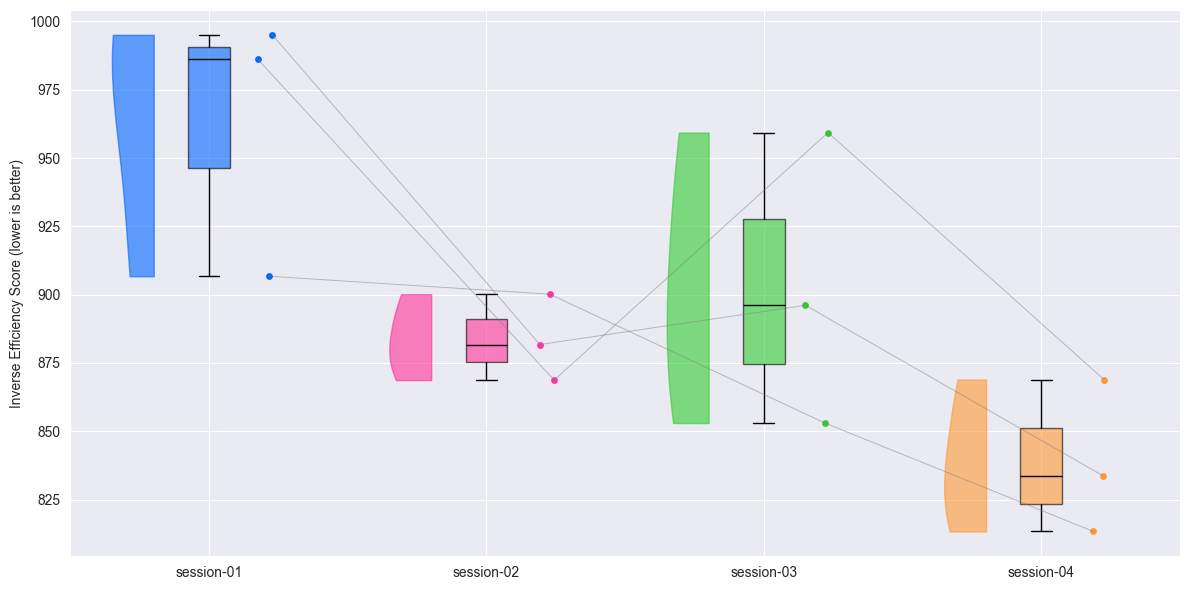

In [5]:
all_session_labels = [1, 2, 3, 4]
if all(s in unique_sessions for s in all_session_labels):
    # Calculate IES for all sessions
    IES_dataframe_sessions = utils.analysis_functions.calculate_IES(combined_results_dataframe_all_sessions)

    # Single-pass aggregation & reshape
    IES_pivoted = (
        IES_dataframe_sessions
        .pivot_table(
            index=['subject_id'],
            columns=['session'],
            values='IES',
            aggfunc='mean'
        )
        .reset_index()
    )
    print(IES_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_4_groups(
        IES_pivoted,
        columns=['session-01', 'session-02', 'session-03', 'session-04'],
        output_dir=output_dir,
        ylabel_name='Inverse Efficiency Score (lower is better)',
        plot_name='IES session'
    )

  subject_id     session   congruent  incongruent
0    sub-005  session-02  851.788375   914.892169
1    sub-005  session-03  870.844164   924.515944
2    sub-005  session-04  887.316734   786.799057
3    sub-010  session-02  844.298342   968.666180
4    sub-010  session-03  859.280985   846.321533
5    sub-010  session-04  800.350473   826.906738
6    sub-011  session-04  755.217123   894.926243
7    sub-014  session-02  890.106545   846.574025
8    sub-014  session-03  974.593982   941.980850
9    sub-014  session-04  871.388835   866.401774


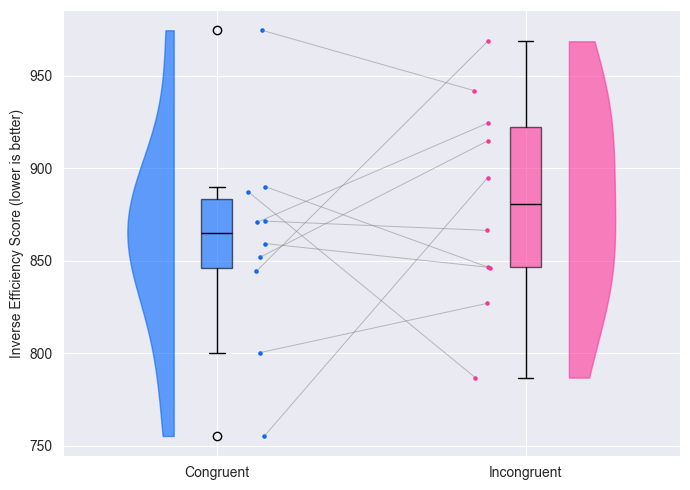

In [6]:
# Single-pass aggregation & reshape
IES_pivoted = (
    IES_dataframe_congruency
    .pivot_table(
        index=['subject_id', 'session'],
        columns='congruency',
        values='IES',
        aggfunc='mean'
    )
    .reset_index()
)
IES_pivoted = IES_pivoted.rename_axis(None, axis=1)
print(IES_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    IES_pivoted,
    column_1='congruent',
    column_2='incongruent',
    labels=['Congruent', 'Incongruent'],
    output_dir=output_dir,
    ylabel_name='Inverse Efficiency Score (lower is better)',
    plot_name='IES congruency'
)

  subject_id     session      stable     volatile
0    sub-005  session-02  778.885984  1051.890902
1    sub-005  session-03  869.834197   932.464367
2    sub-005  session-04  791.327115   894.198955
3    sub-010  session-02  899.550508   900.964500
4    sub-010  session-03  850.215688   856.369498
5    sub-010  session-04  763.111570   892.965329
6    sub-011  session-04  820.448505   816.661736
7    sub-014  session-02  893.510629   838.694016
8    sub-014  session-03  939.838860   981.057099
9    sub-014  session-04  808.786992   962.829447


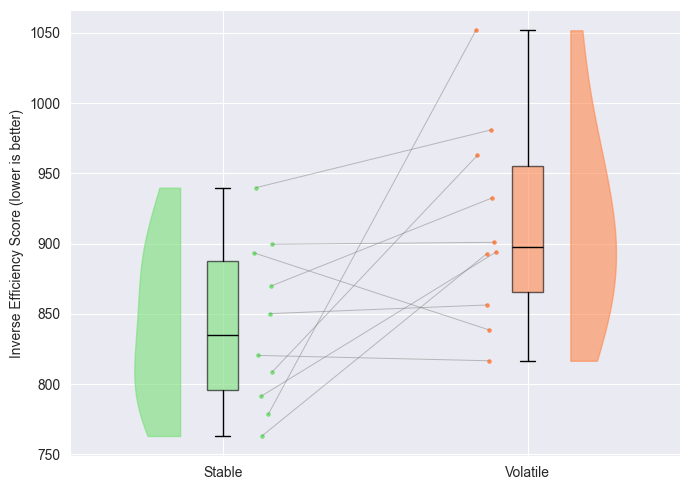

In [7]:
# Single-pass aggregation & reshape
IES_pivoted = (
    IES_dataframe_volatility
    .pivot_table(
        index=['subject_id', 'session'],
        columns='volatility',
        values='IES',
        aggfunc='mean'
    )
    .reset_index()
)
IES_pivoted = IES_pivoted.rename_axis(None, axis=1)
print(IES_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    IES_pivoted,
    column_1='stable',
    column_2='volatile',
    labels=['Stable', 'Volatile'],
    output_dir=output_dir,
    ylabel_name='Inverse Efficiency Score (lower is better)',
    plot_name='IES volatility',
    colours=['#77DF77', '#FF884D']
)

  subject_id     session  congruent_stable  congruent_volatile  \
0    sub-005  session-02        739.710575         1021.387755   
1    sub-005  session-03        895.363805          840.934214   
2    sub-005  session-04        868.765869          910.877257   
3    sub-010  session-02        852.703798          833.500189   
4    sub-010  session-03        849.488456          870.400000   
5    sub-010  session-04        731.458719          925.487713   
6    sub-011  session-04        737.078159          778.642215   
7    sub-014  session-02        919.120000          855.080910   
8    sub-014  session-03        926.331055         1035.327358   
9    sub-014  session-04        810.173523          971.224490   

   incongruent_stable  incongruent_volatile  
0          819.293975           1089.728502  
1          844.146492           1053.440406  
2          729.066626            877.508651  
3          958.052943            981.498000  
4          850.840308            840.217421

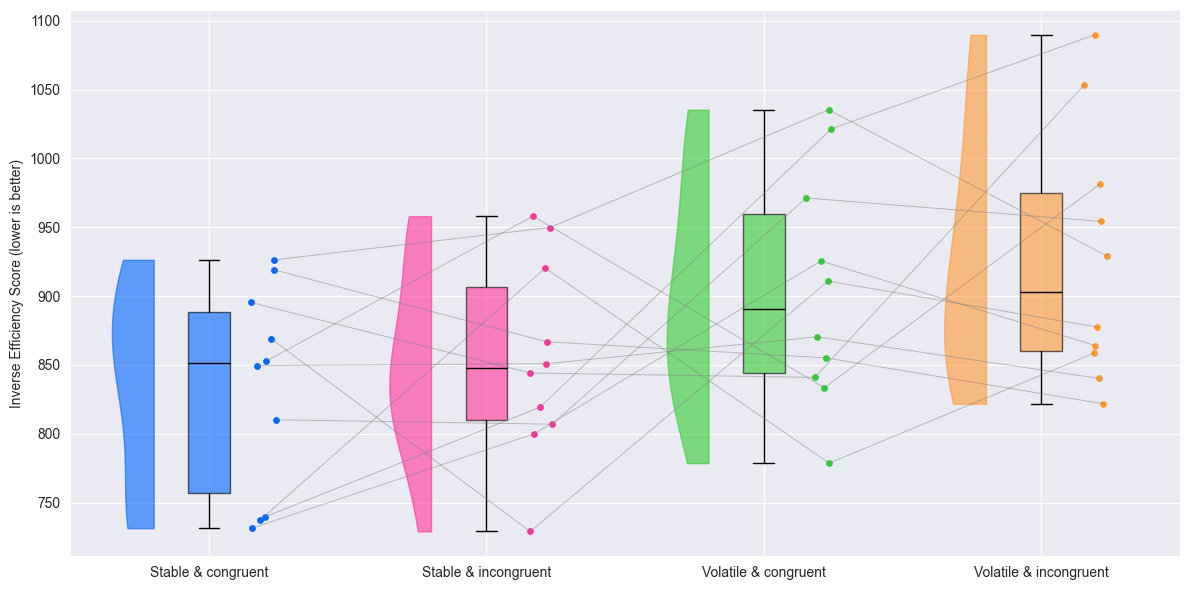

In [8]:
# Single-pass aggregation & reshape
IES_pivoted = (
    IES_dataframe_congruency_volatility
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['congruency', 'volatility'],
        values='IES',
        aggfunc='mean'
    )
    .reset_index()
)
IES_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in IES_pivoted.columns
]
print(IES_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    IES_pivoted,
    columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
    labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
    output_dir=output_dir,
    ylabel_name='Inverse Efficiency Score (lower is better)',
    plot_name='IES congruency & volatility'
)

   subject_id     session   congruency volatility       RT_ms  \
0     sub-005  session-01    congruent     stable  699.050562   
1     sub-005  session-01    congruent   volatile  740.794393   
2     sub-005  session-01  incongruent     stable  758.860656   
3     sub-005  session-01  incongruent   volatile  775.000000   
4     sub-005  session-02    congruent     stable  647.246753   
5     sub-005  session-02    congruent   volatile  670.285714   
6     sub-005  session-02  incongruent     stable  662.407895   
7     sub-005  session-02  incongruent   volatile  689.093023   
8     sub-005  session-03    congruent     stable  676.186207   
9     sub-005  session-03    congruent   volatile  670.474576   
10    sub-005  session-03  incongruent     stable  680.006897   
11    sub-005  session-03  incongruent   volatile  684.736264   
12    sub-005  session-04    congruent     stable  617.789062   
13    sub-005  session-04    congruent   volatile  609.303030   
14    sub-005  session-04

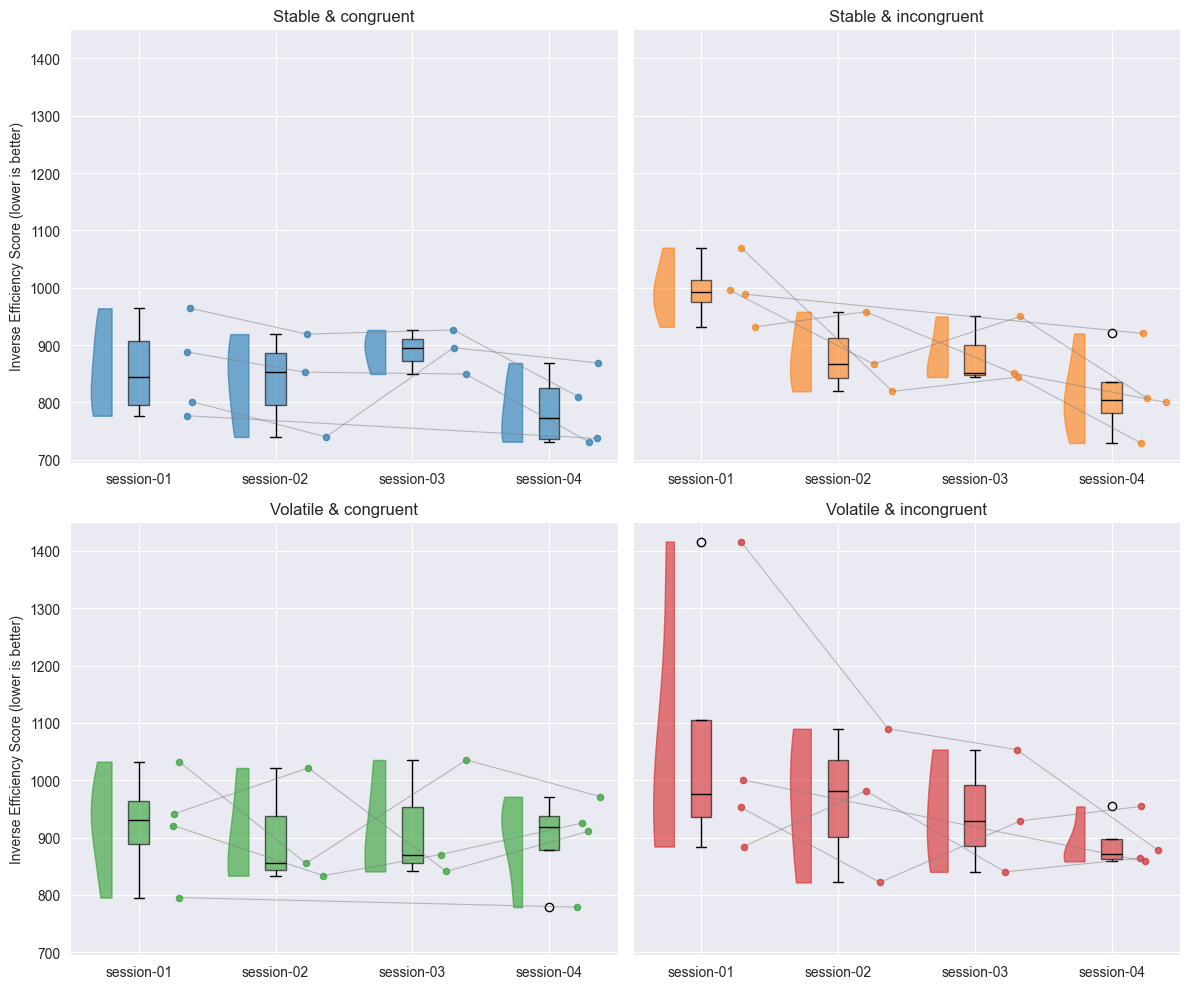

In [9]:
if all(s in unique_sessions for s in all_session_labels):
    # Calculate IES for all sessions
    IES_dataframe_congruency_volatility = utils.analysis_functions.calculate_IES(combined_results_dataframe_all_sessions, ['congruency', 'volatility'])

    # Single-pass aggregation & reshape
    IES_dataframe = (
        IES_dataframe_congruency_volatility
        .pivot_table(
            index=['subject_id', 'session'],
            columns=['congruency', 'volatility'],
            values='IES',
            aggfunc='mean'
        )
        .reset_index()
    )
    IES_dataframe.columns = [
        f"{a}_{b}" if b else a
        for a, b in IES_dataframe.columns
    ]
    print(IES_dataframe)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_scatter_violin_box_2x2(
        IES_dataframe,
        columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
        subject_col='subject_id',
        session_col='session',
        labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
        output_dir=output_dir,
        ylabel_name='Inverse Efficiency Score (lower is better)',
        plot_name='IES sessions, congruency & volatility'
    )

# LISAS
Linear Integrated Speed-Accuracy Score = mean RT in condition j (ms) + overall RT SD / overall proportion of errors SD * proportion of errors in condition j (0.10 for example)

In [10]:
LISAS_dataframe_sessions = utils.analysis_functions.calculate_LISAS(combined_results_dataframe)
LISAS_dataframe_congruency = utils.analysis_functions.calculate_LISAS(combined_results_dataframe, ['congruency'])
LISAS_dataframe_volatility = utils.analysis_functions.calculate_LISAS(combined_results_dataframe, ['volatility'])
LISAS_dataframe_congruency_volatility = utils.analysis_functions.calculate_LISAS(combined_results_dataframe, ['congruency', 'volatility'])

  subject_id     session  RT_ms_mean  error_rate_mean
0    sub-005  session-02  672.506061         0.246970
1    sub-005  session-03  686.234848         0.243939
2    sub-005  session-04  619.616667         0.257576
3    sub-010  session-02  674.268182         0.265152
4    sub-010  session-03  675.521212         0.219697
5    sub-010  session-04  653.278788         0.210606
6    sub-011  session-04  451.795732         0.446646
7    sub-014  session-02  546.407576         0.351515
8    sub-014  session-03  623.751138         0.345979
9    sub-014  session-04  659.912121         0.250000
   subject_id     session   congruency    RT_ms_sd  error_rate_sd
0     sub-005  session-02    congruent  147.635247       0.420924
1     sub-005  session-02  incongruent  145.531331       0.442246
2     sub-005  session-03    congruent  128.912111       0.419164
3     sub-005  session-03  incongruent  122.594412       0.440682
4     sub-005  session-04    congruent  120.942223       0.462341
5     sub-

   subject_id     session  RT_ms_mean  error_rate_mean
0     sub-005  session-01  755.804545         0.260606
1     sub-005  session-02  672.506061         0.246970
2     sub-005  session-03  686.234848         0.243939
3     sub-005  session-04  619.616667         0.257576
4     sub-010  session-01  677.525758         0.262121
5     sub-010  session-02  674.268182         0.265152
6     sub-010  session-03  675.521212         0.219697
7     sub-010  session-04  653.278788         0.210606
8     sub-011  session-01  465.257576         0.468013
9     sub-011  session-04  451.795732         0.446646
10    sub-014  session-01  623.821212         0.357576
11    sub-014  session-02  546.407576         0.351515
12    sub-014  session-03  623.751138         0.345979
13    sub-014  session-04  659.912121         0.250000
   subject_id     session    RT_ms_sd  error_rate_sd
0     sub-005  session-01  152.679337       0.439298
1     sub-005  session-02  146.714318       0.431576
2     sub-005  s

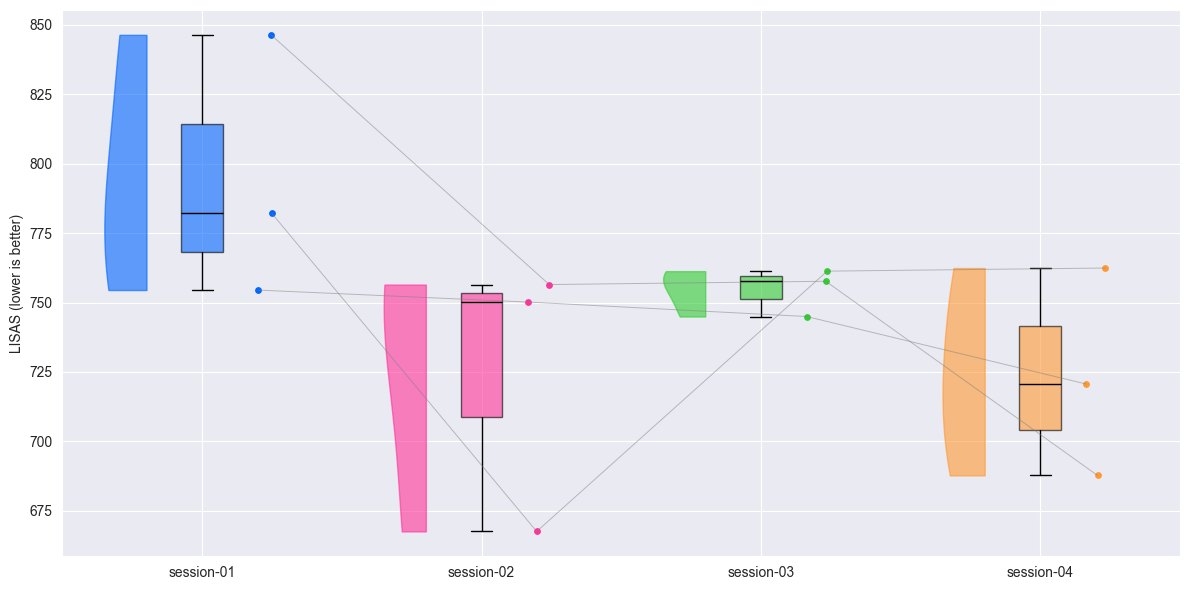

In [11]:
if all(s in unique_sessions for s in all_session_labels):
    # Calculate LISAS for all sessions
    LISAS_dataframe_sessions = utils.analysis_functions.calculate_LISAS(combined_results_dataframe_all_sessions)

    # Single-pass aggregation & reshape
    LISAS_pivoted = (
        LISAS_dataframe_sessions
        .pivot_table(
            index=['subject_id'],
            columns=['session'],
            values='LISAS',
            aggfunc='mean'
        )
        .reset_index()
    )
    print(LISAS_pivoted)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud_4_groups(
        LISAS_pivoted,
        columns=['session-01', 'session-02', 'session-03', 'session-04'],
        output_dir=output_dir,
        ylabel_name='LISAS (lower is better)',
        plot_name='LISAS session'
    )

  subject_id     session   congruent  incongruent
0    sub-005  session-02  759.128522   753.777178
1    sub-005  session-03  761.257383   754.096950
2    sub-005  session-04  686.994977   689.639491
3    sub-010  session-02  746.342473   752.217526
4    sub-010  session-03  745.039679   744.908072
5    sub-010  session-04  721.033104   720.310075
6    sub-011  session-04  585.294669   595.291848
7    sub-014  session-02  674.540396   659.384921
8    sub-014  session-03  751.993818   768.110891
9    sub-014  session-04  760.245150   764.657277


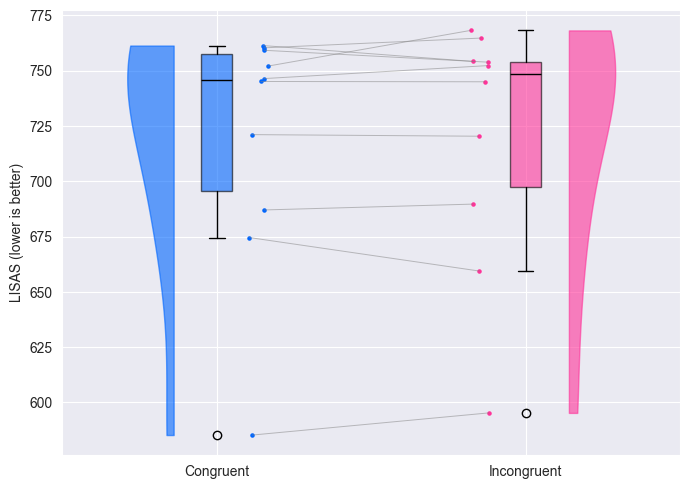

In [12]:
# Single-pass aggregation & reshape
LISAS_pivoted = (
    LISAS_dataframe_congruency
    .pivot_table(
        index=['subject_id', 'session'],
        columns='congruency',
        values='LISAS',
        aggfunc='mean'
    )
    .reset_index()
)
LISAS_pivoted = LISAS_pivoted.rename_axis(None, axis=1)
print(LISAS_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    LISAS_pivoted,
    column_1='congruent',
    column_2='incongruent',
    labels=['Congruent', 'Incongruent'],
    output_dir=output_dir,
        ylabel_name='LISAS (lower is better)',
        plot_name='LISAS congruency'
)

In [13]:
# Single-pass aggregation & reshape
LISAS_pivoted = (
    LISAS_dataframe_volatility
    .pivot_table(
        index=['subject_id', 'session'],
        columns='volatility',
        values='LISAS',
        aggfunc='mean'
    )
    .reset_index()
)
LISAS_pivoted = LISAS_pivoted.rename_axis(None, axis=1)
print(LISAS_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_2_groups(
    LISAS_pivoted,
    column_1='stable',
    column_2='volatile',
    labels=['Stable', 'Volatile'],
    output_dir=output_dir,
        ylabel_name='LISAS (lower is better)',
        plot_name='LISAS volatility',
        colours=['#77DF77', '#FF884D']
)

NameError: name 'LISAS_dataframe_volatility' is not defined

  subject_id     session  congruent_stable  congruent_volatile  \
0    sub-005  session-02        771.988001          755.921106   
1    sub-005  session-03        761.563094          760.916212   
2    sub-005  session-04        690.361936          683.139394   
3    sub-010  session-02        741.975158          751.582455   
4    sub-010  session-03        740.682773          749.311713   
5    sub-010  session-04        732.954682          715.869105   
6    sub-011  session-04        584.983364          585.711766   
7    sub-014  session-02        678.968422          668.436557   
8    sub-014  session-03        764.139004          738.092333   
9    sub-014  session-04        764.812830          755.167940   

   incongruent_stable  incongruent_volatile  
0          757.042681            753.284326  
1          760.420598            749.802517  
2          698.861435            683.691095  
3          751.055717            753.554572  
4          745.023260            744.317626

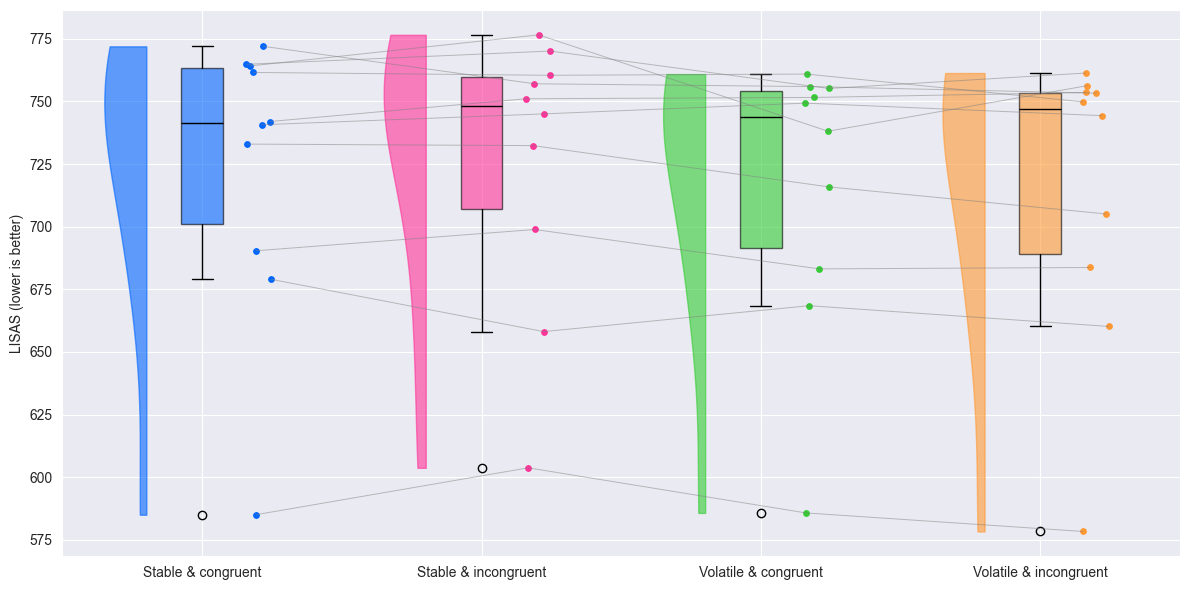

In [14]:
# Single-pass aggregation & reshape
LISAS_pivoted = (
    LISAS_dataframe_congruency_volatility
    .pivot_table(
        index=['subject_id', 'session'],
        columns=['congruency', 'volatility'],
        values='LISAS',
        aggfunc='mean'
    )
    .reset_index()
)
LISAS_pivoted.columns = [
    f"{a}_{b}" if b else a
    for a, b in LISAS_pivoted.columns
]
print(LISAS_pivoted)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud_4_groups(
    LISAS_pivoted,
    columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
    labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
    output_dir=output_dir,
        ylabel_name='LISAS (lower is better)',
        plot_name='LISAS congruency & volatility'
)

   subject_id     session  RT_ms_mean  error_rate_mean
0     sub-005  session-01  755.804545         0.260606
1     sub-005  session-02  672.506061         0.246970
2     sub-005  session-03  686.234848         0.243939
3     sub-005  session-04  619.616667         0.257576
4     sub-010  session-01  677.525758         0.262121
5     sub-010  session-02  674.268182         0.265152
6     sub-010  session-03  675.521212         0.219697
7     sub-010  session-04  653.278788         0.210606
8     sub-011  session-01  465.257576         0.468013
9     sub-011  session-04  451.795732         0.446646
10    sub-014  session-01  623.821212         0.357576
11    sub-014  session-02  546.407576         0.351515
12    sub-014  session-03  623.751138         0.345979
13    sub-014  session-04  659.912121         0.250000
   subject_id     session   congruency volatility    RT_ms_sd  error_rate_sd
0     sub-005  session-01    congruent     stable  121.820027       0.334298
1     sub-005  sessio

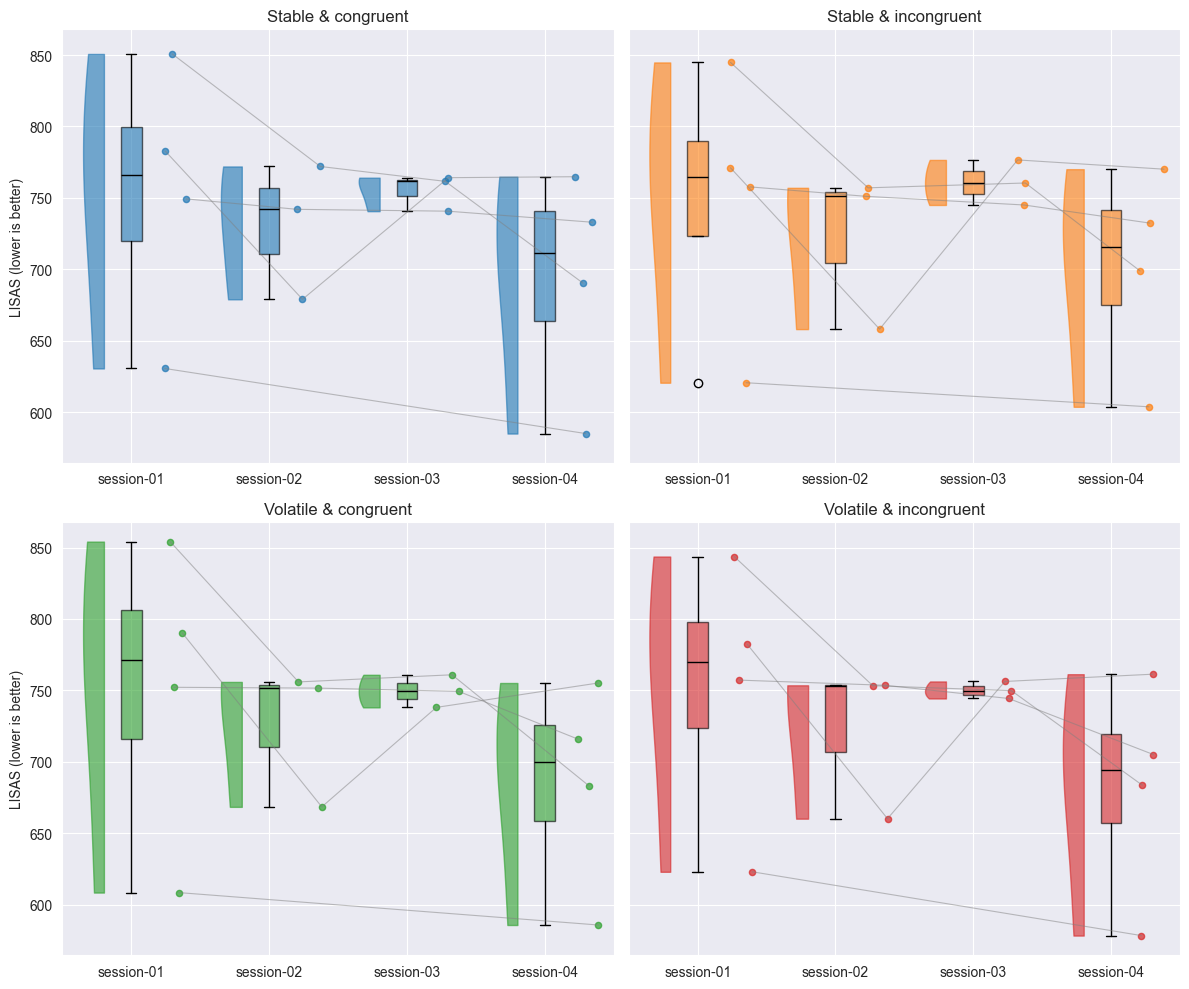

In [15]:
if all(s in unique_sessions for s in all_session_labels):
    # Calculate IES for all sessions
    LISAS_dataframe_congruency_volatility = utils.analysis_functions.calculate_LISAS(combined_results_dataframe_all_sessions, ['congruency', 'volatility'])

    # Single-pass aggregation & reshape
    LISAS_dataframe = (
        LISAS_dataframe_congruency_volatility
        .pivot_table(
            index=['subject_id', 'session'],
            columns=['congruency', 'volatility'],
            values='LISAS',
            aggfunc='mean'
        )
        .reset_index()
    )
    LISAS_dataframe.columns = [
        f"{a}_{b}" if b else a
        for a, b in LISAS_dataframe.columns
    ]
    print(LISAS_dataframe)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_scatter_violin_box_2x2(
        LISAS_dataframe,
        columns=['congruent_stable','incongruent_stable','congruent_volatile','incongruent_volatile'],
        subject_col='subject_id',
        session_col='session',
        labels=['Stable & congruent','Stable & incongruent','Volatile & congruent','Volatile & incongruent'],
        output_dir=output_dir,
        ylabel_name='LISAS (lower is better)',
        plot_name='LISAS sessions, congruency & volatility'
    )

# Plot the relation between speed and accuracy
Quantile probability function

In [16]:
quadratic_trend = False

In [17]:
# suppose your original DataFrame is called df
summary = (
    combined_results_dataframe
    .groupby(['subject_id', 'session', 'congruency'])
    .agg(
        mean_reaction_time=('RT_ms', 'mean'),
        mean_performance=('objectively_correct_boolean', 'mean')
    )
    .reset_index()
)

print(summary)

   subject_id     session   congruency  mean_reaction_time  mean_performance
0     sub-005  session-02    congruent          664.636905          0.770833
1     sub-005  session-02  incongruent          680.666667          0.734568
2     sub-005  session-03    congruent          683.967647          0.773529
3     sub-005  session-03  incongruent          688.643750          0.737500
4     sub-005  session-04    congruent          617.006098          0.692073
5     sub-005  session-04  incongruent          622.195783          0.792169
6     sub-010  session-02    congruent          655.735632          0.755747
7     sub-010  session-02  incongruent          694.939103          0.711538
8     sub-010  session-03    congruent          677.188235          0.767647
9     sub-010  session-03  incongruent          673.750000          0.793750
10    sub-010  session-04    congruent          653.174699          0.798193
11    sub-010  session-04  incongruent          653.384146          0.780488

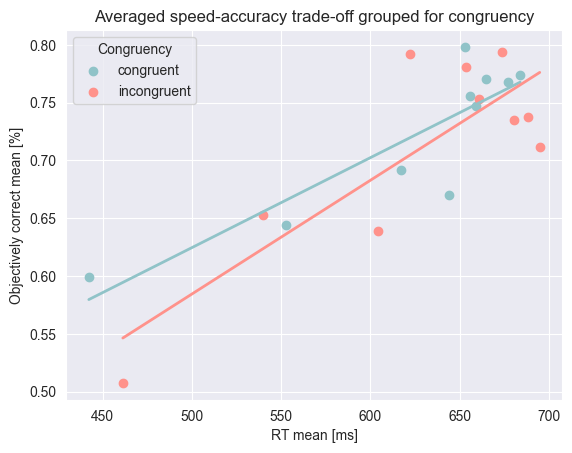

In [18]:
x_col = 'mean_reaction_time'
y_col = 'mean_performance'
group_col = 'congruency'

# Define colours for each group
colour_map = {
    'congruent':   '#90C3C8',
    'incongruent': '#FF928B',
}

fig, ax = plt.subplots()

for cong, group in summary.groupby(group_col):
    x = group[x_col].values
    y = group[y_col].values
    col = colour_map.get(cong, 'gray')

    # Only the scatter gets a legend label
    ax.scatter(x, y, color=col, label=cong)

    # Fit a trendline
    if quadratic_trend:
        a, b, c = np.polyfit(x, y, deg=2)
        x_smooth = np.linspace(x.min(), x.max(), 200)
        y_smooth = a*x_smooth**2 + b*x_smooth + c

        ax.plot(x_smooth, y_smooth, color=col, linewidth=2, label='_nolegend_')
    else:
        m, c = np.polyfit(x, y, deg=1)
        x_line = np.array([x.min(), x.max()])
        y_line = m*x_line + c

        ax.plot(x_line, y_line, color=col, linewidth=2, label='_nolegend_')

ax.set_xlabel('RT mean [ms]')
ax.set_ylabel('Objectively correct mean [%]')
plot_name = 'Averaged speed-accuracy trade-off grouped for congruency'
ax.set_title(plot_name)
ax.legend(title='Congruency')
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

In [19]:
# suppose your original DataFrame is called df
summary = (
    combined_results_dataframe
    .groupby(['subject_id', 'session', 'volatility'])
    .agg(
        mean_reaction_time=('RT_ms', 'mean'),
        mean_performance=('objectively_correct_boolean', 'mean')
    )
    .reset_index()
)

print(summary)

   subject_id     session volatility  mean_reaction_time  mean_performance
0     sub-005  session-02     stable          661.357143          0.840659
1     sub-005  session-02   volatile          686.216216          0.645270
2     sub-005  session-03     stable          684.610215          0.779570
3     sub-005  session-03   volatile          688.333333          0.725694
4     sub-005  session-04     stable          622.255435          0.785326
5     sub-005  session-04   volatile          616.291096          0.688356
6     sub-010  session-02     stable          673.690217          0.733696
7     sub-010  session-02   volatile          674.996575          0.736301
8     sub-010  session-03     stable          679.925824          0.788462
9     sub-010  session-03   volatile          670.104730          0.770270
10    sub-010  session-04     stable          658.221053          0.847368
11    sub-010  session-04   volatile          646.571429          0.710714
12    sub-011  session-04

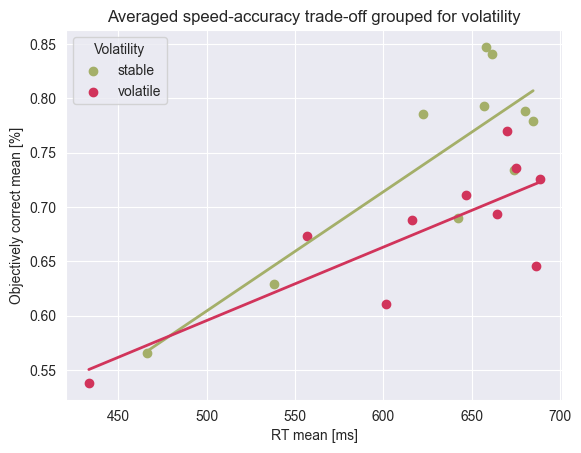

In [20]:
x_col = 'mean_reaction_time'
y_col = 'mean_performance'
group_col = 'volatility'

# Define colours for each group
colour_map = {
    'stable':   '#A4AF69',
    'volatile': '#D1345B',
}

fig, ax = plt.subplots()

for cong, group in summary.groupby(group_col):
    x = group[x_col].values
    y = group[y_col].values
    col = colour_map.get(cong, 'gray')

    # Only the scatter gets a legend label
    ax.scatter(x, y, color=col, label=cong)

    # Fit a trendline
    if quadratic_trend:
        a, b, c = np.polyfit(x, y, deg=2)
        x_smooth = np.linspace(x.min(), x.max(), 200)
        y_smooth = a*x_smooth**2 + b*x_smooth + c

        ax.plot(x_smooth, y_smooth, color=col, linewidth=2, label='_nolegend_')
    else:
        m, c = np.polyfit(x, y, deg=1)
        x_line = np.array([x.min(), x.max()])
        y_line = m*x_line + c

        ax.plot(x_line, y_line, color=col, linewidth=2, label='_nolegend_')

ax.set_xlabel('RT mean [ms]')
ax.set_ylabel('Objectively correct mean [%]')
plot_name = 'Averaged speed-accuracy trade-off grouped for volatility'
ax.set_title(plot_name)
ax.legend(title='Volatility')
os.makedirs(output_dir, exist_ok=True)
fig.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

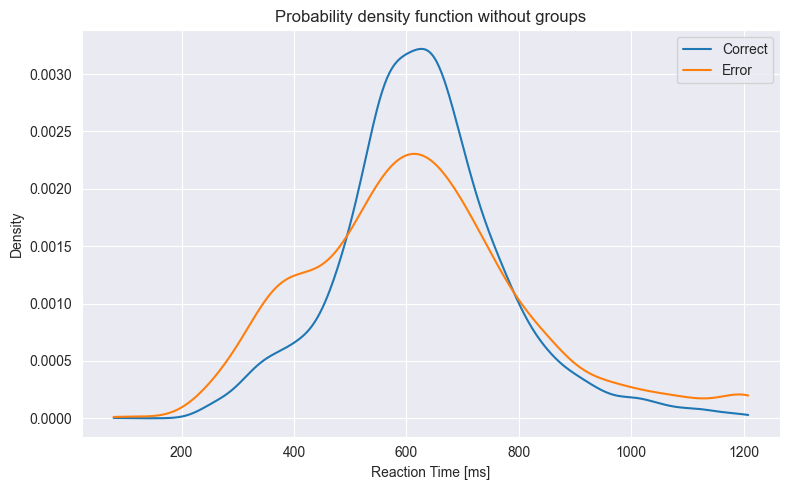

In [21]:
# assume `df` is your DataFrame
# split RTs by correctness
rts_correct = combined_results_dataframe.loc[combined_results_dataframe['objectively_correct_boolean'] == 1, 'RT_ms']
rts_error   = combined_results_dataframe.loc[combined_results_dataframe['objectively_correct_boolean'] == 0, 'RT_ms']

# compute KDEs
kde_correct = gaussian_kde(rts_correct)
kde_error   = gaussian_kde(rts_error)

# choose a common x‐axis range
xmin, xmax = combined_results_dataframe['RT_ms'].min(), combined_results_dataframe['RT_ms'].max()
x_vals = np.linspace(xmin, xmax, 500)

# plot both densities
plt.figure(figsize=(8, 5))
plt.plot(x_vals, kde_correct(x_vals), label='Correct')
plt.plot(x_vals, kde_error(  x_vals), label='Error')
plt.xlabel('Reaction Time [ms]')
plt.ylabel('Density')
plot_name = 'Probability density function without groups'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

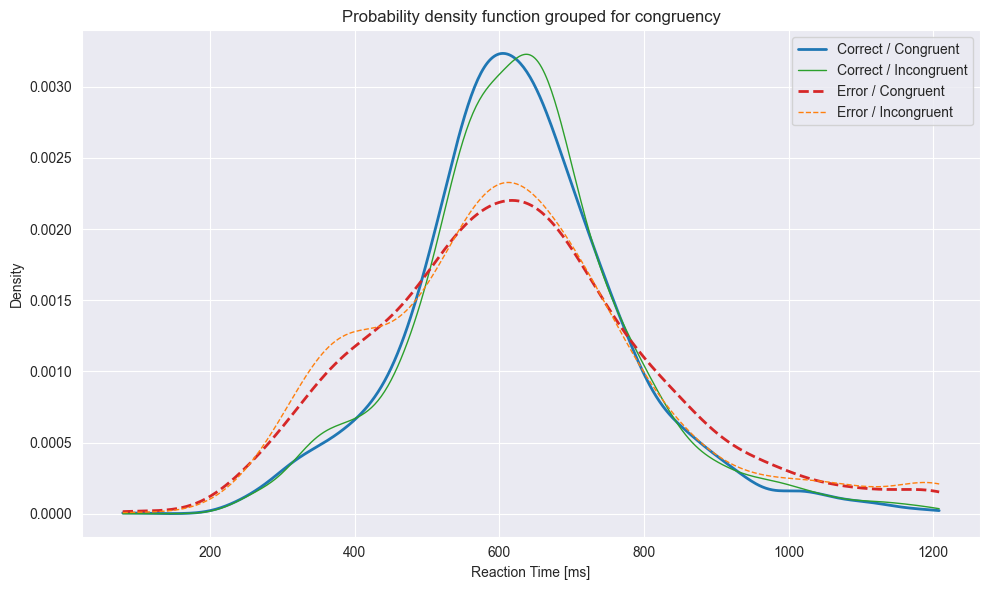

In [22]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['congruent', 'incongruent']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'congruent'):   'tab:blue',
    (1, 'incongruent'): 'tab:green',
    (0, 'congruent'):   'tab:red',
    (0, 'incongruent'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_ms'].min(), combined_results_dataframe['RT_ms'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for cong in ['congruent', 'incongruent']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['congruency'] == cong)
        ]['RT_ms']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {cong.capitalize()}"
        c = color_map[(obj_val, cong)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if cong == 'congruent' else 1)

# finalize
plt.xlabel('Reaction Time [ms]')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for congruency'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

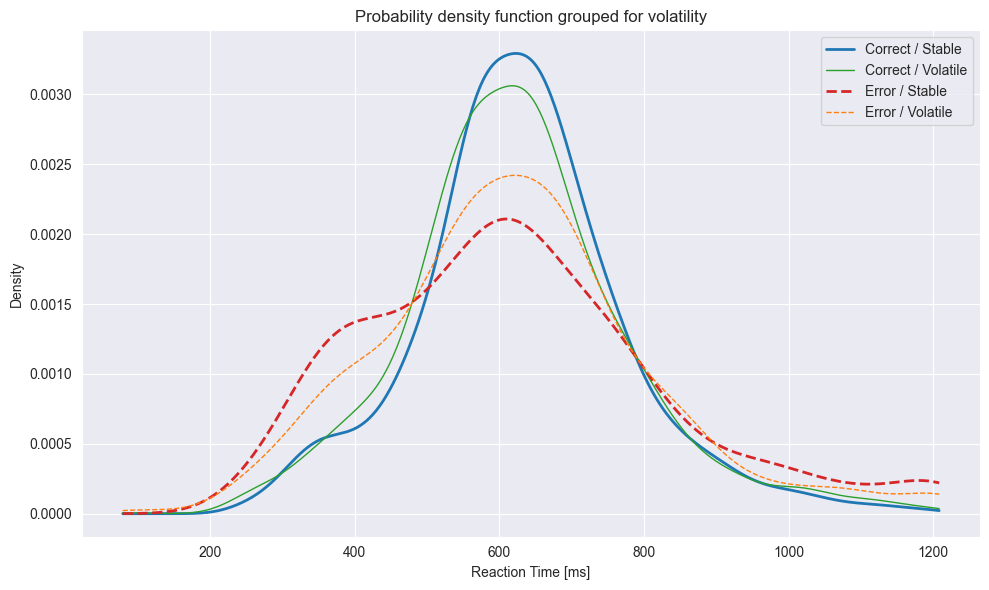

In [23]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['stable', 'volatile']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'stable'):   'tab:blue',
    (1, 'volatile'): 'tab:green',
    (0, 'stable'):   'tab:red',
    (0, 'volatile'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_ms'].min(), combined_results_dataframe['RT_ms'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for volatility in ['stable', 'volatile']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['volatility'] == volatility)
        ]['RT_ms']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {volatility.capitalize()}"
        c = color_map[(obj_val, volatility)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if volatility == 'stable' else 1)

# finalize
plt.xlabel('Reaction Time [ms]')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for volatility'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()

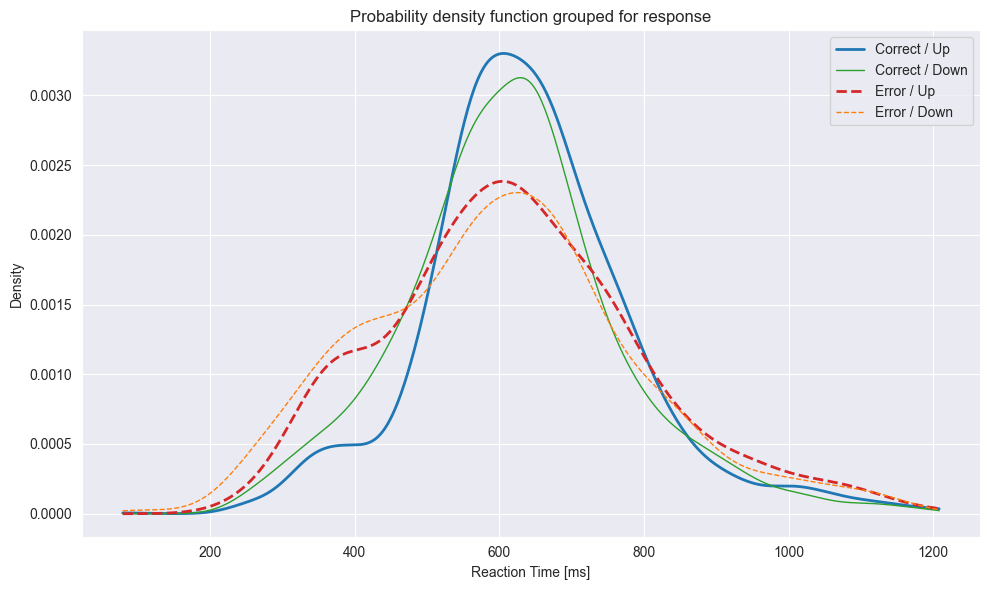

In [24]:
# define your two factors
correctness_levels = {
    1: 'Correct',
    0: 'Error'
}
congruency_levels = ['up', 'down']

# Define your color map for (correctness, congruency)
color_map = {
    (1, 'up'):   'tab:blue',
    (1, 'down'): 'tab:green',
    (0, 'up'):   'tab:red',
    (0, 'down'): 'tab:orange'
}

# Prepare x-axis
xmin, xmax = combined_results_dataframe['RT_ms'].min(), combined_results_dataframe['RT_ms'].max()
x_vals = np.linspace(xmin, xmax, 500)

plt.figure(figsize=(10, 6))

# Loop through each combination
for obj_val, obj_label in [(1, 'Correct'), (0, 'Error')]:
    for response_direction in ['up', 'down']:
        subset = combined_results_dataframe[
            (combined_results_dataframe['objectively_correct_boolean'] == obj_val) &
            (combined_results_dataframe['response'] == response_direction)
        ]['RT_ms']
        if len(subset) < 2:
            continue

        kde = gaussian_kde(subset)
        label = f"{obj_label} / {response_direction.capitalize()}"
        c = color_map[(obj_val, response_direction)]

        plt.plot(x_vals, kde(x_vals),
                 label=label,
                 color=c,
                 linestyle='-' if obj_val == 1 else '--',
                 linewidth=2 if response_direction == 'up' else 1)

# finalize
plt.xlabel('Reaction Time [ms]')
plt.ylabel('Density')
plot_name = 'Probability density function grouped for response'
plt.title(plot_name)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{plot_name}.pdf"))
plt.show()